# Домашнее задание 3. Линейная интерполяция

## Введение

На практике физические свойства газа (вязкость, коэффициент сверхсжимаемости, объёмный коэффициент и др.) известны лишь в дискретных точках — из лабораторных измерений или табличных расчётов. Чтобы получить значение свойства при произвольном давлении, необходима **интерполяция**.

**Линейная интерполяция** — простейший и наиболее распространённый метод: между двумя соседними известными точками $(x_i,\, y_i)$ и $(x_{i+1},\, y_{i+1})$ значение приближается прямой линией:

$$
y_p = y_i + \frac{y_{i+1} - y_i}{x_{i+1} - x_i} \cdot (x_p - x_i)
$$

где $x_p$ — точка, в которой нужно найти значение, а $y_p$ — результат интерполяции.

## Задание

### Что нужно сделать

1. **Считать файл `interp_data.csv`** и загрузить данные давления и вязкости.

2. **Дополнить таблицу столбцами Z и Bg** — используя класс `Fluid` из ДЗ-2, рассчитать коэффициент сверхсжимаемости и объёмный коэффициент расширения для каждого давления при фиксированной температуре $T = 310$ К.

3. **Реализовать класс `LinearInterpolator`** — собственный линейный интерполятор **без использования** встроенных функций интерполяции (numpy, scipy, pandas и т.д.).
   - Класс инициализируется массивами `x` и `y`.
   - Метод `predict(xp)` возвращает интерполированное значение $y_p$ для заданного $x_p$.

4. **Сравнить свой интерполятор с `numpy.interp`** — построить графики, на которых видно совпадение (или расхождение) результатов.

---

## Часть 1. Загрузка и обогащение данных

Считайте файл `interp_data.csv`. Затем вставьте свой класс `Fluid` из ДЗ-2 (с реализованными методами `get_Z` и `get_Bg`) и создайте объект `Fluid` со своими параметрами из `hw2_data.csv`.

Для каждого давления из таблицы рассчитайте Z и Bg при $T = 310$ К и добавьте результаты как новые столбцы.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class Fluid:
    """Класс для расчёта свойств природного газа по методике GERG-91 мод."""
    
    Pstd = 1       # стандартное давление, атм
    Tstd = 293.15  # стандартная температура, К
    R = 0.00831451
    
    def __init__(self, rho_c: float, xa: float, xy: float):
        self.rho_c = rho_c
        self.xa = xa/100
        self.xy = xy/100
    
    def get_Z(self, P: float, T: float) -> float:
        P_mpa = P * 0.101325
        xa = self.xa              
        xy = self.xy             
        xz = 1 - xa - xy

        z_c = 1 - (0.0741 * self.rho_c - 0.006 - 0.063 * xa - 0.0575 * xy)**2

        M3 = (24.05525 * z_c * self.rho_c - 28.0135 * xa - 44.01 * xy) / xz
        H = 128.64 + 47.479 * M3

        B1 = (-0.425468 + 2.865e-3 * T - 4.62073e-6 * T**2 +
          (8.77118e-4 - 5.56281e-6 * T + 8.8151e-9 * T**2) * H +
          (-8.24747e-7 + 4.31436e-9 * T - 6.08319e-12 * T**2) * H**2)
        B2 = -0.1446 + 7.4091e-4 * T - 9.1195e-7 * T**2
        B23 = -0.339693 + 1.61176e-3 * T - 2.04429e-6 * T**2
        B3 = -0.86834 + 4.0376e-3 * T - 5.1657e-6 * T**2


        C1 = (-0.302488 + 1.95861e-3 * T - 3.16302e-6 * T**2 +
          (6.46422e-4 - 4.22876e-6 * T + 6.88157e-9 * T**2) * H +
          (-3.32805e-7 + 2.2316e-9 * T - 3.67713e-12 * T**2) * H**2)
        C2 = 7.8498e-3 - 3.9895e-5 * T + 6.1187e-8 * T**2
        C3 = 2.0513e-3 + 3.4888e-5 * T - 8.3703e-8 * T**2
        C223 = 5.52066e-3 - 1.68609e-5 * T + 1.57169e-8 * T**2
        C233 = 3.58783e-3 + 8.06674e-6 * T - 3.25798e-8 * T**2

        B_star = 0.72 + 1.875e-5 * (320 - T)**2
        C_star = 0.92 + 0.0013 * (T - 270)

        Bm = (xz**2 * B1 + xz * xa * B_star * (B1 + B2) - 1.73 * xz * xy * (B1 * B3)**0.5 + xa**2 * B2 + 2 * xa * xy * B23 + xy**2 * B3)
        Cm = (xz**3 * C1 + 
              3 * xz**2 * xa * C_star * (C1**2 * C2)**(1/3) + 
              2.76 * xz**2 * xy * (C1**2 * C3)**(1/3) + 
              3 * xz * xa**2 * C_star * (C1 * C2**2)**(1/3) + 
              6.6 * xz * xa * xy * (C1 * C2 * C3)**(1/3) + 
              2.76 * xz * xy**2 * (C1 * C3**2)**(1/3) + 
              xa**3 * C2 + 
              3 * xa**2 * xy * C223 + 
              3 * xa * xy**2 * C233 + 
              xy**3 * C3)

        b = 1000 * P_mpa / (2.7715 * T)
        C0 = b**2 * Cm
        B0 = b * Bm
        A1 = 1 + B0
        A0 = 1 + 1.5 * (B0 + C0)
        A2 = (A0 - (A0**2 - A1**3)**0.5)**(1/3)
        z = (1 + A2 + A1 / A2)/3
        return z
    
    def get_Bg(self, P: float, T: float) -> float:
        Z = self.get_Z(P, T)
        Bg = (self.Pstd * Z * T) / (P * self.Tstd)
        return Bg
        

# === Загрузка данных ===

df = pd.read_csv('interp_data.csv', sep=';')
display(df.head())

# === Создание объекта Fluid (подставьте свои параметры из hw2_data.csv) ===

rho_c = 0.6799 
xa = 0.0651     
xy = 0.9489     

fluid = Fluid(rho_c=rho_c, xa=xa, xy=xy)

T = 310

df['Z'] = df['pressure, atm'].apply(lambda P: fluid.get_Z(P, T).real)
df['Bg'] = df['pressure, atm'].apply(lambda P: fluid.get_Bg(P, T).real)

print(df.head(5))

,"pressure, atm","viscosity, cP"
0,1.000000,0.018312
1,3.010101,0.018321
2,5.020202,0.018330
3,7.030303,0.018339
4,9.040404,0.018349


   pressure, atm  viscosity, cP         Z        Bg
0       1.000000       0.018312  0.998471  1.055862
1       3.010101       0.018321  0.995406  0.349696
2       5.020202       0.018330  0.992352  0.209034
3       7.030303       0.018339  0.989309  0.148809
4       9.040404       0.018349  0.986279  0.115368


---

## Часть 2. Собственный интерполятор

Реализуйте класс `LinearInterpolator`.

### Требования

- `__init__(self, x, y)` — принимает два списка (или массива) одинаковой длины. Значения `x` должны быть отсортированы по возрастанию.
- `predict(self, xp)` — принимает скалярное значение `xp` и возвращает интерполированное значение `yp`.
- **Запрещено** использовать `numpy`, `scipy`, `pandas` и любые другие библиотечные функции интерполяции внутри класса. Только чистый Python (`list`, `for`, `if`, арифметика).

### Подсказка

Алгоритм для `predict(xp)`:
1. Найти индекс $i$ такой, что $x_i \le x_p < x_{i+1}$.
2. Применить формулу линейной интерполяции:

$$
y_p = y_i + \frac{y_{i+1} - y_i}{x_{i+1} - x_i} \cdot (x_p - x_i)
$$

> Что делать, если `xp` совпадает с последней точкой $x_n$? Обработайте этот граничный случай через экстраполяцию по двум граничным точкам

In [2]:
class LinearInterpolator:
    def __init__(self, x, y):
        if len(x) != len(y):
            raise ValueError("Разная длина списков")
        self.x = list(x)
        self.y = list(y)

    def predict(self, xp):
        # На случай, если последняя xn = xp
        if xp == self.x[-1]:
            x0, x1 = self.x[-2], self.x[-1]
            y0, y1 = self.y[-2], self.y[-1]
            k = (y1 - y0) / (x1 - x0)
            return y1 + k * (xp - x1)

        for i in range(len(self.x) - 1):
            if self.x[i] <= xp < self.x[i + 1]:
                x0, x1 = self.x[i], self.x[i + 1]
                y0, y1 = self.y[i], self.y[i + 1]
                k = (y1 - y0) / (x1 - x0)
                return y0 + k * (xp - x0)

---

## Часть 3. Сравнение с `numpy.interp`

Сгенерируйте набор промежуточных точек давления (например, 500 точек в диапазоне от 1 до 200 атм). Вычислите интерполированные значения **вязкости**, **Z** и **Bg** двумя способами:

1. Ваш `LinearInterpolator`
2. Функция `numpy.interp`

Постройте графики, на которых отображены:
- Исходные табличные точки (маркерами)
- Кривая вашего интерполятора
- Кривая `numpy.interp`

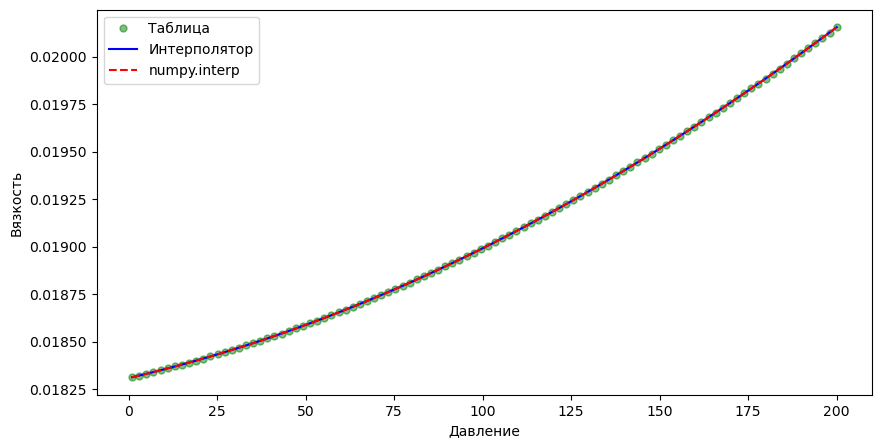

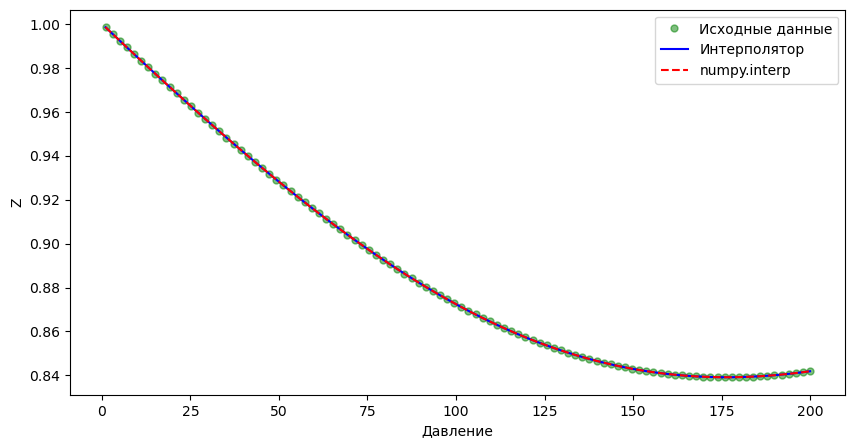

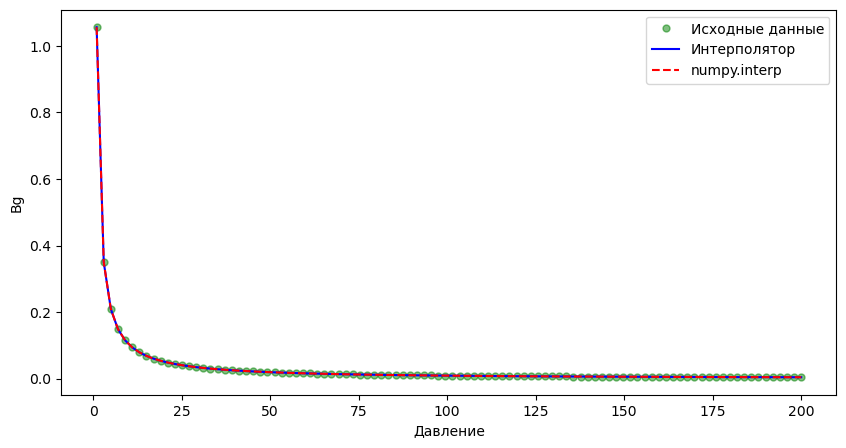

In [4]:
x_test = np.linspace(1, 200, 100)

x_data = df['pressure, atm'].values
y_viscosity = df['viscosity, cP'].values
y_Z = df['Z'].values
y_Bg = df['Bg'].values

interp_visc = LinearInterpolator(x_data, y_viscosity)
interp_Z = LinearInterpolator(x_data, y_Z)
interp_Bg = LinearInterpolator(x_data, y_Bg)

y_visc_my = [interp_visc.predict(xp) for xp in x_test]
y_Z_my = [interp_Z.predict(xp) for xp in x_test]
y_Bg_my = [interp_Bg.predict(xp) for xp in x_test]

y_visc_numpy = np.interp(x_test, x_data, y_viscosity)
y_Z_numpy = np.interp(x_test, x_data, y_Z)
y_Bg_numpy = np.interp(x_test, x_data, y_Bg)

#Графики
plt.figure(figsize=(10, 5))
plt.plot(x_data, y_viscosity, 'go', markersize=5, alpha=0.5, label='Таблица')
plt.plot(x_test, y_visc_my, 'b-', label='Интерполятор')
plt.plot(x_test, y_visc_numpy, 'r--', label='numpy.interp')
plt.xlabel('Давление')
plt.ylabel('Вязкость')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(x_data, y_Z, 'go', markersize=5, alpha=0.5, label='Исходные данные')
plt.plot(x_test, y_Z_my, 'b-', label='Интерполятор')
plt.plot(x_test, y_Z_numpy, 'r--', label='numpy.interp')
plt.xlabel('Давление')
plt.ylabel('Z')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(x_data, y_Bg, 'go', markersize=5, alpha=0.5, label='Исходные данные')
plt.plot(x_test, y_Bg_my, 'b-', label='Интерполятор')
plt.plot(x_test, y_Bg_numpy, 'r--', label='numpy.interp')
plt.xlabel('Давление')
plt.ylabel('Bg')
plt.legend()
plt.show()